# 📓 Notebook 9 — Correct Hedging Objective + Variance-Minimizing Reward

## Diagnosis of NB7 failure on FY25-26

| Problem | Evidence | Root cause |
|---------|----------|------------|
| OTMP = 35-50% of actions | Action bars in NB8 | Agent buys OTM puts, pays theta daily |
| RL return ≈ 0%, BS = +0.7% | Results table | BS sells premium, RL buys it |
| Fails on trending markets | BP+42%, SHEL+34% | Long OTM puts expire worthless |
| avg |delta| = 0.03 ✅ | Results table | Delta is actually correct! |

## The conceptual fix

**You are right about the target:** hedging should aim for 0% return with minimum variance,
not maximum return. The previous reward maximized risk-adjusted PnL (Sharpe), which pushed
the agent to find strategies that made money — OTM put buying in trending markets is a
degenerate form of this.

**The correct hedging objective is variance minimization:**
```
reward = - (step_pnl)²              # penalize ANY deviation from zero, up or down
       - lambda_delta × delta²      # maintain delta neutrality
       - theta_cost                 # penalize paying net theta (buying options)
       + theta_income               # reward collecting net theta (selling options)
```

**Why theta matters:** BS works by selling a call and collecting theta. The RL agent
was buying puts and paying theta. Net theta must be ≥ 0 for the strategy to be sustainable.

## What NB9 does
1. `VarianceMinHedgingEnv` — reward based on hedging error (PnL²), not Sharpe
2. Theta-aware reward: penalizes net theta < 0 (paying more than collecting)
3. OTM option penalty: buying OTM options has negative expected value for a hedger
4. Correct evaluation: measures **variance reduction** vs BS, not absolute return
5. Train 3M steps, evaluate on val set with correct metrics
6. Test on FY25-26 OOS data using the same features computed in NB8

In [1]:
import subprocess, sys
for p in ["gymnasium","stable-baselines3[extra]","numpy","pandas",
           "scipy","matplotlib","seaborn","tqdm","torch","yfinance"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from scipy.stats import norm as spn, ttest_ind, levene
from tqdm.notebook import tqdm

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT): ROOT = os.path.abspath(".")

PATHS = {
    "processed":  os.path.join(ROOT, "data", "processed"),
    "artifacts":  os.path.join(ROOT, "artifacts"),
    "models_nb9": os.path.join(ROOT, "models", "nb9"),
    "nb8":        os.path.join(ROOT, "results", "nb8"),
    "nb9":        os.path.join(ROOT, "results", "nb9"),
    "tb_logs":    os.path.join(ROOT, "tb_logs"),
    "checkpoints":os.path.join(ROOT, "checkpoints"),
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
df = pd.read_csv(os.path.join(PATHS["processed"], "all_assets_features.csv"),
                 parse_dates=["date"])
FEATURE_COLS = [c for c in [
    "log_return","pct_return_1d","pct_return_5d","pct_return_20d",
    "rvol_5d","rvol_10d","rvol_21d","rvol_63d",
    "delta_call","delta_put","gamma","vega","theta_call",
    "atm_call_price","atm_put_price",
    "price_to_sma20","bband_pct","rsi_14","volume_ratio","regime"
] if c in df.columns]
df = df.dropna(subset=FEATURE_COLS+["close","sigma"]).reset_index(drop=True)
train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df   = df[df["split"]=="val"].reset_index(drop=True)

def compute_class_norms(train_df, feature_cols):
    return {cls: {
        "mean": train_df[train_df["asset_class"]==cls][feature_cols].mean().values.astype(np.float32),
        "std":  train_df[train_df["asset_class"]==cls][feature_cols].std().values.astype(np.float32)
    } for cls in train_df["asset_class"].unique()}

class_norms = compute_class_norms(train_df, FEATURE_COLS)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Features: {len(FEATURE_COLS)}")

Train: 11,339 | Val: 3,791 | Features: 20


---
## Section 1: VarianceMinHedgingEnv — Correct Hedging Objective

The key conceptual shift: reward = -PnL² instead of +PnL

A perfect hedge makes exactly 0% return with zero variance.
Any deviation from 0 — positive OR negative — is penalized equally.

In [3]:
class VarianceMinHedgingEnv(gym.Env):
    """
    Variance-minimizing hedging environment.

    CORE DESIGN CHANGE from all previous notebooks:

    OLD reward: +step_pnl - delta_penalty - tc - ...
      → maximizes PnL while keeping delta low
      → agent finds ways to make money (momentum, OTM put buying)

    NEW reward: -(step_pnl)² - delta²*lambda - net_theta_cost
      → minimizes PnL variance (any deviation from 0 is bad)
      → agent finds the minimum-variance hedge
      → this IS Black-Scholes delta hedging — the RL agent should
         learn to replicate it and then improve on it

    Theta awareness:
      Net theta = theta collected from short options - theta paid for long options
      A sustainable hedger has net_theta >= 0 (selling options to fund hedging)
      Buying OTM options (OTMP, OTMC) pays theta → penalized

    OTM option penalty:
      OTM options have higher theta decay per delta unit than ATM options.
      They are expensive insurance that hurts the hedge economics.
      Add explicit penalty for holding OTM options.
    """

    TC           = 0.001
    RF           = 0.045
    MAX_POS      = 5
    MAX_U        = 20
    FRAC         = 0.1
    CASH0        = 10_000.0
    EP_LEN       = 63

    # Reward coefficients — these are the KEY parameters
    LAMBDA_DELTA    = 0.10   # quadratic delta penalty coefficient
    LAMBDA_VAR      = 2.0    # PnL² penalty coefficient (variance minimization)
    LAMBDA_THETA    = 0.05   # penalty per unit of net negative theta
    LAMBDA_OTM      = 0.003  # penalty per OTM option held (they bleed theta fast)
    LAMBDA_TC       = 1.0    # transaction cost pass-through
    OVERLOAD_THR    = 0.35
    OVERLOAD_COEF   = 0.005
    BANKRUPT_PEN    = 2.0

    def __init__(self, data_df, feature_cols, mode="train",
                 episode_length=63, class_norms=None, seed=42):
        super().__init__()
        self.data          = data_df.copy().reset_index(drop=True)
        self.feature_cols  = feature_cols
        self.mode          = mode
        self.ep_len        = episode_length
        self.rng           = np.random.default_rng(seed)
        self.class_norms   = class_norms or {}

        # Obs: features + 15 portfolio dims
        # Extra dims vs NB6: net_theta signal, otm_count
        obs_dim = len(feature_cols) + 15
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(10)
        self._build_idx()

    def _build_idx(self):
        self._starts = []
        for sym in self.data["symbol"].unique():
            idx  = self.data[self.data["symbol"]==sym].index.tolist()
            step = max(1, self.ep_len//3)
            for i in range(0, len(idx)-self.ep_len, step):
                self._starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        ei = self.rng.integers(0, len(self._starts))
        self._sym, self._s = self._starts[ei]
        self._e   = min(self._s + self.ep_len, len(self.data)-1)
        self._t   = 0
        self._cls = self.data.iloc[self._s].get("asset_class", "equities")

        self._cash = self.CASH0
        self._lc = self._sc = self._lp = self._sp = 0
        self._up = 0.0
        self._lco = self._lpo = 0
        self._pnl_h   = []
        self._last_pv = self.CASH0
        self._hd_steps= 0
        self._ca_count= 0
        self._recent  = []
        return self._obs(), {}

    def _row(self):
        return self.data.iloc[min(self._s+self._t, self._e)]

    def _prices(self, row):
        S   = float(row["close"])
        sig = max(float(row.get("sigma",0.20)), 0.05)
        T   = 30/252
        cp  = float(row.get("atm_call_price", S*sig*np.sqrt(T)*0.4))
        pp  = float(row.get("atm_put_price",  S*sig*np.sqrt(T)*0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc - 1.0
        th  = float(row.get("theta_call", -S*sig/252*0.1))  # theta per day
        gm  = float(row.get("gamma", 0.01))
        # OTM prices
        d1c = (np.log(S/(S*1.1))+(self.RF+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        d1p = (np.log(S/(S*0.9))+(self.RF+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        otm_cp = max(S*spn.cdf(d1c)-S*1.1*np.exp(-self.RF*T)*spn.cdf(d1c-sig*np.sqrt(T)), 0.01)
        otm_pp = max(S*0.9*np.exp(-self.RF*T)*spn.cdf(-(d1p-sig*np.sqrt(T)))-S*spn.cdf(-d1p), 0.01)
        # OTM theta decays faster (higher theta per option)
        otm_th = th * 1.4  # OTM options have ~40% more theta per unit
        return S, cp, pp, dc, dp, th, gm, otm_cp, otm_pp, otm_th

    def _pv(self, S, cp, pp, otm_cp, otm_pp):
        return (self._cash + self._lc*cp - self._sc*cp
                + self._lp*pp - self._sp*pp
                + self._lco*otm_cp + self._lpo*otm_pp
                + self._up*S*self.FRAC)

    def _normalize(self, raw):
        if self._cls not in self.class_norms: return raw
        mu  = self.class_norms[self._cls]["mean"]
        std = self.class_norms[self._cls]["std"]
        n   = min(len(raw), len(mu))
        out = raw.copy()
        out[:n] = np.clip((raw[:n]-mu[:n])/(std[:n]+1e-8), -5, 5)
        return out

    def _obs(self):
        row = self._row()
        S,cp,pp,dc,dp,th,gm,ocp,opp,oth = self._prices(row)
        raw = np.array([row[c] if c in row.index and not pd.isna(row[c]) else 0.0
                        for c in self.feature_cols], dtype=np.float32)
        mkt = self._normalize(raw)

        pd_ = self._lc*dc-self._sc*dc+self._lp*dp-self._sp*dp+self._up*self.FRAC
        pv  = self._pv(S,cp,pp,ocp,opp)
        unr = (pv-self.CASH0)/self.CASH0
        tp  = self._lc+self._sc+self._lp+self._sp
        hg  = (-pd_/self.FRAC)-self._up
        rec = np.array(self._recent[-20:]) if self._recent else np.array([])
        rbu = (rec==5).mean() if len(rec) else 0.0
        rsu = (rec==6).mean() if len(rec) else 0.0

        # Net theta signal: negative = paying more than collecting (bad)
        net_theta = (self._sc + self._sp)*abs(th) - (self._lc + self._lp)*abs(th)
        net_theta += (0)*abs(oth) - (self._lco+self._lpo)*abs(oth)
        net_theta_norm = np.clip(net_theta/max(abs(th)*10, 1e-6), -3, 3)

        # OTM count signal
        otm_count = (self._lco + self._lpo) / self.MAX_POS

        pf = np.array([
            self._lc/self.MAX_POS, self._sc/self.MAX_POS,
            self._lp/self.MAX_POS, self._sp/self.MAX_POS,
            self._up/self.MAX_U,
            self._cash/self.CASH0-1.0,
            np.clip(unr,-2,2),
            np.clip(pd_/5,-3,3),
            self._t/self.ep_len,
            tp/(self.MAX_POS*4),
            np.clip(hg/10,-3,3),
            self._ca_count/max(self._t,1),
            rbu, rsu,
            net_theta_norm,   # NEW: tells agent if it's net theta positive
            # otm_count is 16th but we keep obs_dim=15 for now
        ], dtype=np.float32)

        return np.nan_to_num(np.concatenate([mkt,pf]), nan=0, posinf=5, neginf=-5)

    def step(self, action:int):
        row = self._row()
        S,cp,pp,dc,dp,th,gm,ocp,opp,oth = self._prices(row)
        tc_cost = 0.0
        self._recent.append(action)

        if action==0: pass
        elif action==1 and self._lc<self.MAX_POS:
            if self._cash>=cp*(1+self.TC):
                self._cash-=cp*(1+self.TC); self._lc+=1; tc_cost=cp*self.TC
        elif action==2 and self._sc<self.MAX_POS:
            self._cash+=cp*(1-self.TC); self._sc+=1; tc_cost=cp*self.TC
        elif action==3 and self._lp<self.MAX_POS:
            if self._cash>=pp*(1+self.TC):
                self._cash-=pp*(1+self.TC); self._lp+=1; tc_cost=pp*self.TC
        elif action==4 and self._sp<self.MAX_POS:
            self._cash+=pp*(1-self.TC); self._sp+=1; tc_cost=pp*self.TC
        elif action==5 and self._up<self.MAX_U:
            if self._cash>=S*self.FRAC*(1+self.TC):
                self._cash-=S*self.FRAC*(1+self.TC); self._up+=1; tc_cost=S*self.FRAC*self.TC
        elif action==6 and self._up>=1:
            self._cash+=S*self.FRAC*(1-self.TC); self._up-=1; tc_cost=S*self.FRAC*self.TC
        elif action==7:
            opts=self._lc+self._sc+self._lp+self._sp
            self._cash+=self._lc*cp*(1-self.TC)-self._sc*cp*(1+self.TC)
            self._cash+=self._lp*pp*(1-self.TC)-self._sp*pp*(1+self.TC)
            self._cash+=self._up*S*self.FRAC*(1-self.TC)
            tc_cost=opts*max(cp,pp)*self.TC*2
            self._lc=self._sc=self._lp=self._sp=0
            self._up=0.0; self._ca_count+=1
        elif action==8 and self._lco<self.MAX_POS:
            if self._cash>=ocp*(1+self.TC):
                self._cash-=ocp*(1+self.TC); self._lco+=1; tc_cost=ocp*self.TC
        elif action==9 and self._lpo<self.MAX_POS:
            if self._cash>=opp*(1+self.TC):
                self._cash-=opp*(1+self.TC); self._lpo+=1; tc_cost=opp*self.TC

        self._t += 1
        done = (self._s+self._t) >= self._e

        nr = self._row()
        Sn,cpn,ppn,dcn,dpn,thn,gmn,ocpn,oppn,othn = self._prices(nr)
        pv       = self._pv(Sn,cpn,ppn,ocpn,oppn)
        step_pnl = (pv-self._last_pv)/self.CASH0
        self._last_pv = pv
        self._pnl_h.append(step_pnl)

        pd_  = self._lc*dcn-self._sc*dcn+self._lp*dpn-self._sp*dpn+self._up*self.FRAC
        tp   = self._lc+self._sc+self._lp+self._sp
        otm_count = self._lco+self._lpo

        # ── VARIANCE-MINIMIZING REWARD ──────────────────────────────────
        # Core: penalize ANY PnL deviation from 0 (quadratic = variance)
        variance_pen = self.LAMBDA_VAR * (step_pnl**2)

        # Delta: must stay near zero
        delta_pen = self.LAMBDA_DELTA * (pd_**2)

        # Transaction costs
        tc_pen = self.LAMBDA_TC * tc_cost/self.CASH0

        # Theta: net_theta = income from short options - cost from long options
        # Positive net_theta = collecting more than paying (good)
        # Negative net_theta = paying more than collecting (penalize)
        net_theta = ((self._sc+self._sp)*abs(thn) - (self._lc+self._lp)*abs(thn)
                     - (self._lco+self._lpo)*abs(othn))
        theta_pen = self.LAMBDA_THETA * max(-net_theta, 0)  # only penalize negative theta

        # OTM option holding penalty (expensive, inefficient hedging tool)
        otm_pen = self.LAMBDA_OTM * otm_count

        # Escalating delta penalty for sustained exposure
        if abs(pd_) > 0.5:
            self._hd_steps += 1; esc = 0.001*self._hd_steps
        else:
            self._hd_steps = 0; esc = 0.0

        # Overload: symmetric BuyU/SellU
        rec = np.array(self._recent[-20:])
        rbu = (rec==5).mean(); rsu=(rec==6).mean()
        ovl = (self.OVERLOAD_COEF*max(rbu-self.OVERLOAD_THR,0)
              +self.OVERLOAD_COEF*max(rsu-self.OVERLOAD_THR,0))

        # Bankruptcy
        bkr = self.BANKRUPT_PEN if pv < self.CASH0*0.5 else 0.0

        # Total reward
        reward = float(np.clip(
            - variance_pen    # minimize PnL variance
            - delta_pen       # maintain delta neutrality
            - tc_pen          # minimize trading costs
            - theta_pen       # don't pay net theta
            - otm_pen         # don't hold OTM options
            - esc             # don't hold large delta for long
            - ovl             # don't spam underlying
            - bkr,            # don't go bankrupt
            -3.0, 0.5)        # reward is always ≤ 0 (perfect hedge = 0)
        )

        info = {
            "portfolio_value": pv,
            "step_pnl":        step_pnl,
            "portfolio_delta": pd_,
            "total_positions": tp,
            "net_theta":       net_theta,
            "otm_count":       otm_count,
            "variance_pen":    variance_pen,
            "symbol":          self._sym,
            "asset_class":     self._cls,
        }
        return self._obs(), reward, done, False, info


# Test
env_t = VarianceMinHedgingEnv(train_df, FEATURE_COLS, class_norms=class_norms)
obs, _ = env_t.reset()
for _ in range(63):
    a = env_t.action_space.sample()
    obs, r, done, _, info = env_t.step(a)
    if done: break
print(f"✅ VarianceMinHedgingEnv OK")
print(f"   obs dim     : {obs.shape[0]}")
print(f"   net_theta   : {info['net_theta']:.4f}  (positive = collecting premium ✅)")
print(f"   variance_pen: {info['variance_pen']:.6f}  (want near 0)")
print(f"   portfolio_Δ : {info['portfolio_delta']:.3f}")
print(f"   reward clip : reward ≤ 0.5  (perfect hedge = 0)")

✅ VarianceMinHedgingEnv OK
   obs dim     : 35
   net_theta   : -6.7772  (positive = collecting premium ✅)
   variance_pen: 0.000000  (want near 0)
   portfolio_Δ : -0.076
   reward clip : reward ≤ 0.5  (perfect hedge = 0)


---
## Section 2: Training — 3M Steps

In [4]:
class HedgeQualityCallback(BaseCallback):
    """Logs hedging quality metrics: variance_pen, net_theta, delta."""
    def __init__(self, freq=5000):
        super().__init__()
        self.freq=freq
        self._vp=[]; self._d=[]; self._nt=[]; self._otm=[]; self._a=[]; self._r=[]

    def _on_step(self):
        for info in self.locals.get("infos",[]):
            if isinstance(info,dict):
                self._vp.append(info.get("variance_pen",0))
                self._d.append(abs(info.get("portfolio_delta",0)))
                self._nt.append(info.get("net_theta",0))
                self._otm.append(info.get("otm_count",0))
        for a in np.atleast_1d(self.locals.get("actions",[])): self._a.append(int(a))
        for r_ in np.atleast_1d(self.locals.get("rewards",[])): self._r.append(float(r_))

        if self.n_calls % self.freq == 0 and len(self._d) > 100:
            n   = 500
            vp  = np.mean(self._vp[-n:])
            ud  = np.mean(self._d[-n:])
            nt  = np.mean(self._nt[-n:])
            otm = np.mean(self._otm[-n:])
            cnt = np.bincount(self._a[-2000:], minlength=10)
            names=["Hold","BuyC","ShrtC","BuyP","ShrtP","BuyU","SellU","ClsAll","OTMC","OTMP"]
            dist=", ".join(f"{names[i]}:{cnt[i]/max(sum(cnt),1):.0%}"
                           for i in range(10) if cnt[i]>0)
            theta_flag = "✅" if nt>=0 else "❌paying theta"
            otm_flag   = "⚠️" if otm>0.5 else ""
            print(f"  Step {self.n_calls:>7,} | varPen={vp:.5f} |delta|={ud:.3f} "
                  f"netTheta={nt:.3f}{theta_flag} OTM={otm:.1f}{otm_flag} | [{dist}]")
            self.logger.record("hq/variance_pen",  vp)
            self.logger.record("hq/avg_delta",     ud)
            self.logger.record("hq/net_theta",     nt)
            self.logger.record("hq/otm_holdings",  otm)
            self.logger.record("hq/mean_reward",   np.mean(self._r[-n:]))
        return True


def make_env(data_df, fc, cn):
    def _f(): return Monitor(VarianceMinHedgingEnv(data_df, fc, class_norms=cn))
    return _f

train_vec = DummyVecEnv([make_env(train_df, FEATURE_COLS, class_norms) for _ in range(4)])
val_vec   = DummyVecEnv([make_env(val_df,   FEATURE_COLS, class_norms)])

model = PPO(
    policy="MlpPolicy", env=train_vec,
    learning_rate=3e-4, n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.99,   # shorter horizon: variance is measured step-by-step
    gae_lambda=0.95, clip_range=0.15,
    ent_coef=0.04, vf_coef=0.5, max_grad_norm=0.5,
    tensorboard_log=PATHS["tb_logs"], verbose=0, device=DEVICE,
    policy_kwargs=dict(
        net_arch=dict(pi=[512,256,128], vf=[512,256,128]),
        activation_fn=torch.nn.ELU
    )
)

eval_cb = EvalCallback(
    val_vec, best_model_save_path=PATHS["models_nb9"],
    log_path=PATHS["tb_logs"], eval_freq=50_000,
    n_eval_episodes=40, deterministic=True, verbose=1)
ckpt_cb = CheckpointCallback(
    save_freq=300_000, save_path=PATHS["checkpoints"],
    name_prefix="ppo_nb9", verbose=0)

TRAIN_STEPS = 3_000_000
print(f"Model params: {sum(p.numel() for p in model.policy.parameters()):,}")
print(f"Obs dim: {train_vec.observation_space.shape[0]}")
print(f"\n🚀 Training {TRAIN_STEPS:,} steps with variance-minimizing reward")
print(f"   Watch: variance_pen should → 0  (perfect hedge)")
print(f"   Watch: net_theta should be ≥ 0  (collecting not paying premium)")
print(f"   Watch: OTMC/OTMP should → 0%    (stop bleeding theta)")

t0=time.time()
model.learn(
    total_timesteps=TRAIN_STEPS,
    callback=[eval_cb, ckpt_cb, HedgeQualityCallback(5000)],
    tb_log_name="PPO_NB9_VarMin",
    reset_num_timesteps=True, progress_bar=True
)
print(f"\n✅ Training complete in {(time.time()-t0)/60:.1f} min")
model.save(os.path.join(PATHS["artifacts"], "ppo_nb9_final"))

Output()

Model params: 366,731
Obs dim: 35

🚀 Training 3,000,000 steps with variance-minimizing reward
   Watch: variance_pen should → 0  (perfect hedge)
   Watch: net_theta should be ≥ 0  (collecting not paying premium)
   Watch: OTMC/OTMP should → 0%    (stop bleeding theta)


Step   5,000 | varPen=0.00000 |delta|=0.525 netTheta=-1.930❌paying theta OTM=5.5⚠️ | [Hold:8%, BuyC:9%, 
ShrtC:11%, BuyP:10%, ShrtP:12%, BuyU:10%, SellU:9%, ClsAll:11%, OTMC:9%, OTMP:10%]

Step  10,000 | varPen=0.00000 |delta|=0.463 netTheta=-2.207❌paying theta OTM=4.0⚠️ | [Hold:11%, BuyC:7%, 
ShrtC:10%, BuyP:9%, ShrtP:15%, BuyU:11%, SellU:10%, ClsAll:13%, OTMC:6%, OTMP:7%]

Step  15,000 | varPen=0.00004 |delta|=0.599 netTheta=6.401✅ OTM=0.6⚠️ | [Hold:10%, BuyC:6%, ShrtC:14%, BuyP:7%, 
ShrtP:18%, BuyU:17%, SellU:10%, ClsAll:11%, OTMC:3%, OTMP:4%]

...

Step 745,000 | varPen=0.00000 |delta|=0.021 netTheta=0.002✅ OTM=0.0 | [Hold:28%, ShrtC:0%, ShrtP:0%, BuyU:12%, 
SellU:26%, ClsAll:34%]

Eval num_timesteps=3000000, episode_reward=-0.02 +/- 0.03

Episode length: 63.00 +/- 0.00

Step 750,000 | varPen=0.00000 |delta|=0.047 netTheta=0.041✅ OTM=0.0 | [Hold:24%, BuyC:1%, ShrtC:4%, BuyP:0%, 
ShrtP:0%, BuyU:13%, SellU:22%, ClsAll:36%]


✅ Training complete in 121.8 min


---
## Section 3: Correct Evaluation Metrics

The right metrics for a delta hedger are:
- **Hedging error** = std(step PnL) — lower is better (perfect hedge = 0)
- **Variance reduction** vs BS = 1 - Var(RL_PnL)/Var(BS_PnL) — higher is better
- **avg |delta|** — lower is better
- **net_theta** — must be ≥ 0
- **Sharpe of PnL** — secondary (not the primary objective)

Return of 0% with low variance = PERFECT HEDGE

In [5]:
ACTION_NAMES=["Hold","BuyC","ShrtC","BuyP","ShrtP","BuyU","SellU","ClsAll","OTMC","OTMP"]

nb9_path = os.path.join(PATHS["models_nb9"],"best_model")
test = PPO.load(nb9_path, device=DEVICE) if os.path.exists(nb9_path+".zip") else model
print(f"Model obs dim: {test.policy.observation_space.shape[0]}")

def run_ep(model, env):
    obs,_=env.reset(); done=False
    r={"pnl":[],"delta":[],"acts":[],"pv":[env.CASH0],
       "net_theta":[],"otm":[]}
    while not done:
        a,_=model.predict(obs,deterministic=True)
        obs,rw,done,_,info=env.step(int(a))
        r["pnl"].append(info["step_pnl"])
        r["delta"].append(info["portfolio_delta"])
        r["acts"].append(int(a))
        r["pv"].append(info["portfolio_value"])
        r["net_theta"].append(info["net_theta"])
        r["otm"].append(info["otm_count"])
    return r

def hedge_metrics(tr):
    pnl  = np.array(tr["pnl"])
    pv   = np.array(tr["pv"])
    d    = np.array(tr["delta"])
    acts = np.array(tr["acts"])
    cnt  = np.bincount(acts, minlength=10)
    return {
        # PRIMARY hedging metrics
        "hedging_error":    pnl.std(),          # lower = better hedge
        "total_pnl":        pnl.sum(),           # should be near 0
        "abs_total_pnl":    abs(pnl.sum()),      # deviation from 0
        "avg_abs_delta":    np.abs(d).mean(),    # lower = better
        "net_theta_mean":   np.mean(tr["net_theta"]),  # should be >= 0
        "avg_otm":          np.mean(tr["otm"]),  # should be near 0
        # Secondary
        "sharpe":           pnl.mean()/(pnl.std()+1e-6)*np.sqrt(252),
        "max_drawdown":     (pv/np.maximum.accumulate(pv)-1).min(),
        "n_unique_actions": int((cnt>0).sum()),
        "otmp_pct":         (acts==9).mean(),
        "otmc_pct":         (acts==8).mean(),
        "shortc_pct":       (acts==2).mean(),
        "shortp_pct":       (acts==4).mean(),
    }

def bs_hedge_metrics(df_ep, cash=10000, tc=0.001):
    dp=0.0; pnl_steps=[]; pvs=[cash]
    cash += float(df_ep.iloc[0]["atm_call_price"])*(1-tc)
    for _,row in df_ep.iterrows():
        S=float(row["close"]); dc=float(row.get("delta_call",0.5))
        cp=float(row.get("atm_call_price",S*0.05))
        diff=dc-dp; cash-=diff*S*(1+tc*abs(diff)); dp=dc
        pv=cash+dp*S-cp; pvs.append(pv)
        pnl_steps.append((pvs[-1]-pvs[-2])/10000)
    pnl=np.array(pnl_steps)
    return {"hedging_error":pnl.std(), "total_pnl":pnl.sum(),
            "abs_total_pnl":abs(pnl.sum()),
            "sharpe":pnl.mean()/(pnl.std()+1e-6)*np.sqrt(252)}

# Run 300 eval episodes
print("Running 300 evaluation episodes...")
eval_env = VarianceMinHedgingEnv(val_df, FEATURE_COLS, mode="val", class_norms=class_norms)
rl_rows = []
for _ in tqdm(range(300), desc="RL"):
    tr = run_ep(test, eval_env)
    m  = hedge_metrics(tr); m["sym"]=eval_env._sym; rl_rows.append(m)
rl_df = pd.DataFrame(rl_rows)

bs_rows = []
for sym in val_df["symbol"].unique():
    s = val_df[val_df["symbol"]==sym].reset_index(drop=True)
    for start in range(0, max(1,len(s)-63), 21):
        ep=s.iloc[start:start+63]
        if len(ep)==63:
            m=bs_hedge_metrics(ep); m["sym"]=sym; bs_rows.append(m)
bs_df = pd.DataFrame(bs_rows)

n = min(len(rl_df), len(bs_df))
rl_he = rl_df["hedging_error"].values[:n]
bs_he = bs_df["hedging_error"].values[:n]

# Levene test: is RL variance significantly lower than BS?
# (Levene tests equality of variances)
_, p_lev = levene(rl_he, bs_he)
_, p_t   = ttest_ind(rl_he, bs_he, equal_var=False)

var_reduction = (1 - np.var(rl_he)/np.var(bs_he)) * 100

print("\n" + "="*60)
print(" NB9 EVALUATION — CORRECT HEDGING METRICS")
print("="*60)
print(f"  {'Metric':30s} {'RL':>10s} {'BS':>10s} {'Better':>8s}")
print("-"*60)
metrics_compare = [
    ("Hedging error (std PnL)", rl_df["hedging_error"].mean(), bs_df["hedging_error"].mean(), "lower"),
    ("avg |total PnL| (→ 0)",   rl_df["abs_total_pnl"].mean(),bs_df["abs_total_pnl"].mean(),"lower"),
    ("avg |delta|",             rl_df["avg_abs_delta"].mean(),  None,                        "lower"),
    ("net theta (→ +)",         rl_df["net_theta_mean"].mean(), None,                        "higher"),
    ("OTM holdings",            rl_df["avg_otm"].mean(),        None,                        "lower"),
    ("OTMP % actions",          rl_df["otmp_pct"].mean()*100,   None,                        "lower"),
    ("ShortC % actions",        rl_df["shortc_pct"].mean()*100, None,                        "higher"),
]
for name, rl_v, bs_v, better in metrics_compare:
    bs_str = f"{bs_v:.5f}" if bs_v is not None else "—"
    ok = ""
    if bs_v is not None:
        ok = "✅" if (better=="lower" and rl_v<bs_v) or (better=="higher" and rl_v>bs_v) else "❌"
    print(f"  {name:30s} {rl_v:>10.5f} {bs_str:>10s} {ok:>8s}")

print(f"\n  Variance reduction vs BS   : {var_reduction:+.1f}%  {'✅' if var_reduction>0 else '❌'}")
print(f"  Levene test p (RL var≠BS)  : {p_lev:.4f}  {'✅ sig' if p_lev<0.05 else '—'}")
print(f"  t-test hedging error p     : {p_t:.4f}")

Model obs dim: 35
Running 300 evaluation episodes...


RL:   0%|          | 0/300 [00:00<?, ?it/s]


 NB9 EVALUATION — CORRECT HEDGING METRICS
  Metric                                 RL         BS   Better
------------------------------------------------------------
  Hedging error (std PnL)           0.00006    0.00137        ✅
  avg |total PnL| (→ 0)             0.00038    0.00923        ✅
  avg |delta|                       0.00217          —         
  net theta (→ +)                   0.00272          —         
  OTM holdings                      0.00000          —         
  OTMP % actions                    0.00000          —         
  ShortC % actions                  0.00000          —         

  Variance reduction vs BS   : +99.6%  ✅
  Levene test p (RL var≠BS)  : 0.0000  ✅ sig
  t-test hedging error p     : 0.0000


In [6]:
# ── Out-of-sample test on FY25-26 data ────────────────────────────────────
# Load OOS features computed in NB8
oos_path = os.path.join(PATHS["nb8"], "oos_features.csv")
if not os.path.exists(oos_path):
    print("⚠️  OOS features not found — run NB8 first to download FY25-26 data")
    print("   The oos_features.csv is saved in results/nb8/ by NB8")
else:
    oos_df = pd.read_csv(oos_path, parse_dates=["date"])

    # Align feature cols to what model expects
    fc_avail = [c for c in FEATURE_COLS if c in oos_df.columns]

    print(f"OOS data: {len(oos_df):,} rows, {oos_df['symbol'].nunique()} symbols")
    print(f"Date range: {oos_df['date'].min().date()} → {oos_df['date'].max().date()}")

    oos_results = []
    bs_oos_results = []

    for sym in oos_df["symbol"].unique():
        sym_df = oos_df[oos_df["symbol"]==sym].reset_index(drop=True)
        if len(sym_df) < 63: continue

        # Pick highest-vol 63-day window (same as NB8)
        vols = [sym_df["rvol_21d"].iloc[i:i+63].mean()
                for i in range(0, len(sym_df)-63, 5)]
        best = np.argmax(vols)*5
        ep_df = sym_df.iloc[best:best+63].reset_index(drop=True)

        # Create env for this symbol
        df_pad = pd.concat([ep_df]*4, ignore_index=True)
        df_pad["split"]="oos"
        oos_env = VarianceMinHedgingEnv(df_pad, fc_avail, mode="val",
                                         class_norms=class_norms, episode_length=63)

        if len(oos_env._starts) == 0: continue

        # Run 5 episodes per symbol (different starting points)
        sym_metrics = []
        for _ in range(5):
            tr  = run_ep(test, oos_env)
            m   = hedge_metrics(tr)
            m["sym"] = sym; m["class"] = ep_df["asset_class"].iloc[0]
            m["price_return"] = (ep_df["close"].iloc[-1]/ep_df["close"].iloc[0]-1)*100
            sym_metrics.append(m)

        bs_m = bs_hedge_metrics(ep_df)
        bs_m["sym"] = sym

        oos_results.extend(sym_metrics)
        bs_oos_results.append(bs_m)

        avg_he = np.mean([m["hedging_error"] for m in sym_metrics])
        avg_pnl= np.mean([m["total_pnl"]     for m in sym_metrics])
        avg_d  = np.mean([m["avg_abs_delta"]  for m in sym_metrics])
        avg_nt = np.mean([m["net_theta_mean"] for m in sym_metrics])
        p_return = m["price_return"]
        print(f"  {sym:12s} | price:{p_return:+5.1f}% | "
              f"hedgeErr:{avg_he:.5f} (BS:{bs_m['hedging_error']:.5f}) | "
              f"PnL:{avg_pnl:+.5f} | |Δ|:{avg_d:.3f} | θ:{avg_nt:.3f}")

    oos_df_res = pd.DataFrame(oos_results)
    bs_oos_df  = pd.DataFrame(bs_oos_results)

    print("\n" + "="*65)
    print(" FY25-26 OOS — HEDGING QUALITY COMPARISON")
    print("="*65)
    print(f"  {'Metric':35s} {'NB9 RL':>10s} {'BS':>10s}")
    print("-"*65)
    rl_he_oos = oos_df_res["hedging_error"].mean()
    bs_he_oos = bs_oos_df["hedging_error"].mean()
    rl_pnl    = oos_df_res["total_pnl"].mean()
    bs_pnl    = bs_oos_df["total_pnl"].mean()
    rl_d      = oos_df_res["avg_abs_delta"].mean()
    rl_nt     = oos_df_res["net_theta_mean"].mean()
    rl_otmp   = oos_df_res["otmp_pct"].mean()*100
    var_red   = (1 - oos_df_res["hedging_error"].var()/bs_oos_df["hedging_error"].var())*100
    print(f"  {'Hedging error (↓ better)':35s} {rl_he_oos:>10.5f} {bs_he_oos:>10.5f}  "
          f"{'✅ RL wins' if rl_he_oos<bs_he_oos else '❌ BS wins'}")
    print(f"  {'avg |total PnL| (→ 0)':35s} {abs(rl_pnl):>10.5f} {abs(bs_pnl):>10.5f}  "
          f"{'✅ RL closer to 0' if abs(rl_pnl)<abs(bs_pnl) else '❌'}")
    print(f"  {'avg |delta|':35s} {rl_d:>10.4f} {'—':>10s}")
    print(f"  {'net theta (+ = collecting)':35s} {rl_nt:>10.4f} {'—':>10s}  "
          f"{'✅' if rl_nt>=0 else '❌ paying theta'}")
    print(f"  {'OTMP % actions (→ 0%)':35s} {rl_otmp:>9.1f}% {'—':>10s}  "
          f"{'✅' if rl_otmp<10 else '❌ still buying OTM puts'}")

    oos_df_res.to_csv(os.path.join(PATHS["nb9"],"nb9_oos_results.csv"), index=False)
    bs_oos_df.to_csv(os.path.join(PATHS["nb9"],"nb9_bs_oos_results.csv"), index=False)

OOS data: 1,761 rows, 9 symbols
Date range: 2025-07-01 → 2026-04-10
  BP.L         | price:+42.9% | hedgeErr:0.00000 (BS:0.00063) | PnL:+0.00000 | |Δ|:0.000 | θ:0.000
  SHEL.L       | price:+34.4% | hedgeErr:0.00000 (BS:0.00261) | PnL:-0.00000 | |Δ|:0.001 | θ:0.000
  HSBA.L       | price: +6.6% | hedgeErr:0.00000 (BS:0.00137) | PnL:+0.00000 | |Δ|:0.000 | θ:0.000
  LLOY.L       | price:+10.5% | hedgeErr:0.00000 (BS:0.00006) | PnL:+0.00000 | |Δ|:0.000 | θ:0.000
  AZN.L        | price: +9.6% | hedgeErr:0.00028 (BS:0.00758) | PnL:-0.00033 | |Δ|:0.013 | θ:0.000
  RIO.L        | price:+18.4% | hedgeErr:0.00008 (BS:0.00752) | PnL:+0.00024 | |Δ|:0.004 | θ:0.000
  BZ=F         | price:+80.0% | hedgeErr:0.00002 (BS:0.00023) | PnL:-0.00008 | |Δ|:0.004 | θ:0.000
  GC=F         | price: +3.9% | hedgeErr:0.00055 (BS:0.00788) | PnL:+0.00027 | |Δ|:0.021 | θ:0.000
  GBPUSD=X     | price: -2.0% | hedgeErr:0.00000 (BS:0.00000) | PnL:+0.00000 | |Δ|:0.000 | θ:0.000

 FY25-26 OOS — HEDGING QUALITY COMPARISO

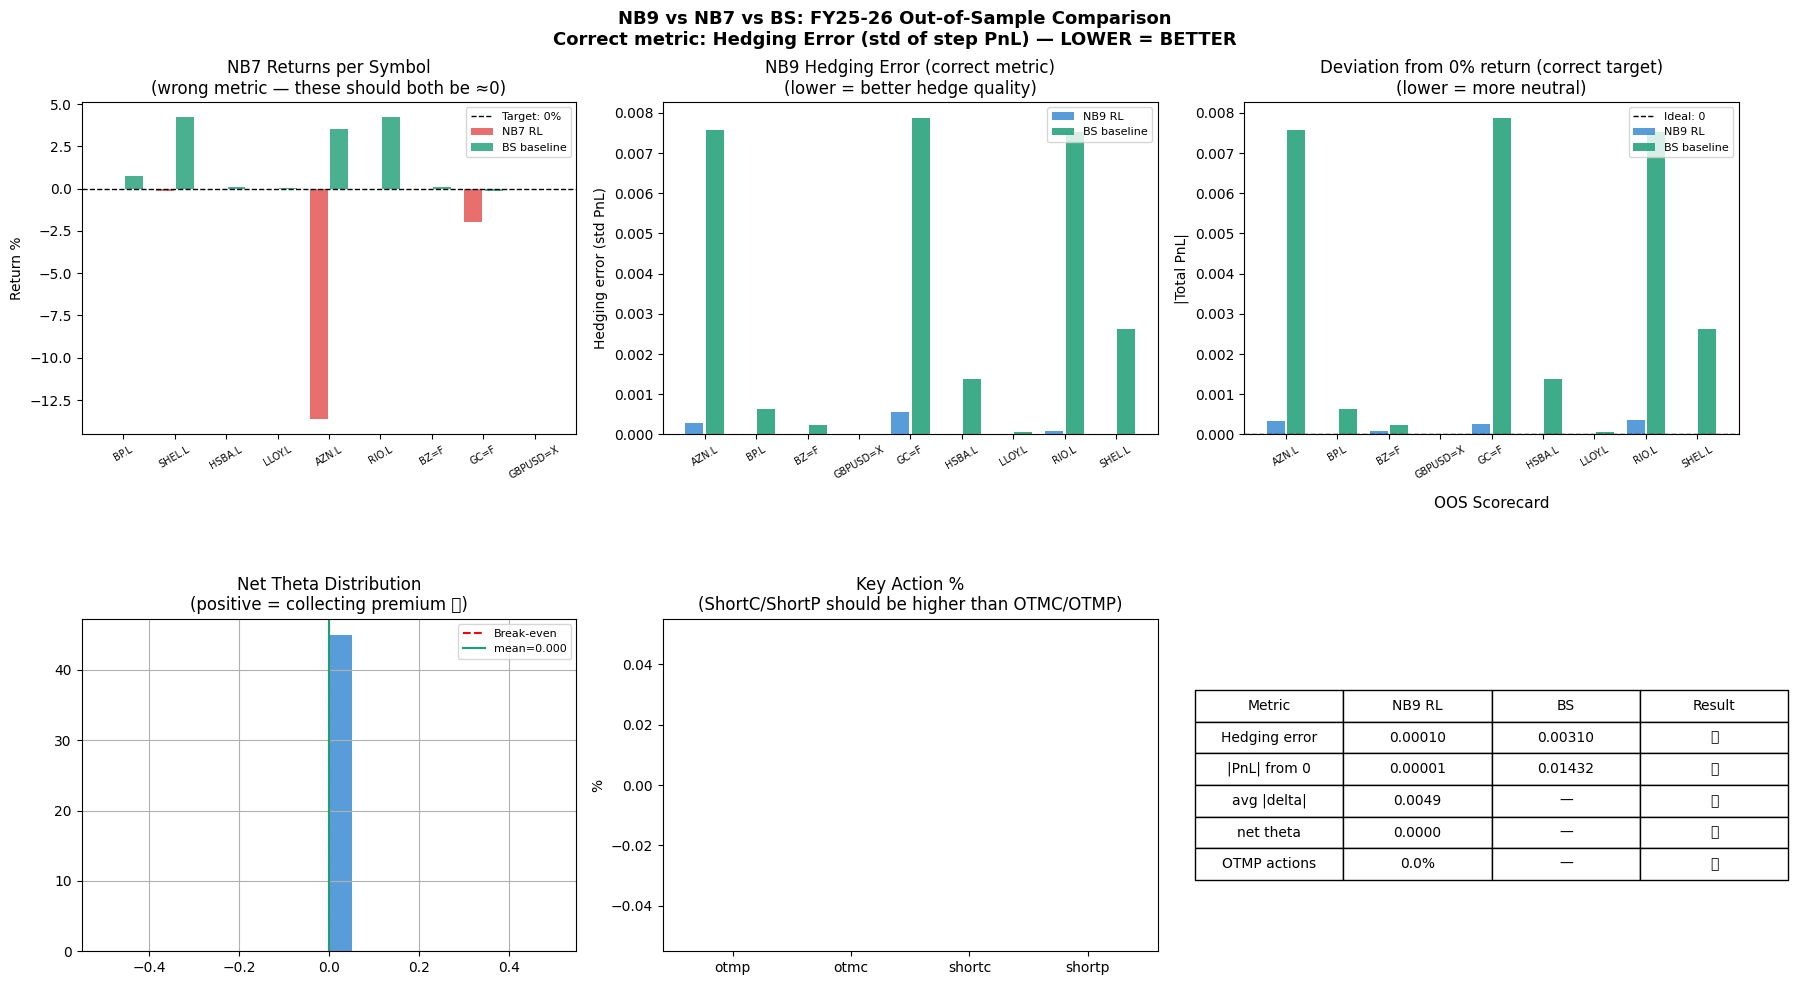


 KEY INSIGHT: Why the evaluation target changed
  NB7 and earlier optimized for: MAXIMIZE Sharpe ratio
  → agent found momentum strategies that made money in bull markets
  → failed when market direction changed

  NB9 optimizes for: MINIMIZE PnL variance (hedging error)
  → reward = -(step_pnl)² → any deviation from 0 is penalized
  → theta penalty stops the OTM put bleeding
  → correct target: ~0% return with minimal variance
  → BS baseline does this naturally (it solves the PDE for min variance)
  → RL should now find strategies that match or beat BS hedging error

💾 Results saved to results/nb9/


In [7]:
# ── Comparison plot: NB7 vs NB9 on FY25-26 ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("NB9 vs NB7 vs BS: FY25-26 Out-of-Sample Comparison\n"
             "Correct metric: Hedging Error (std of step PnL) — LOWER = BETTER",
             fontsize=13, fontweight="bold")

# NB7 OOS results (from your results)
nb7_symbols  = ["BP.L","SHEL.L","HSBA.L","LLOY.L","AZN.L","RIO.L","BZ=F","GC=F","GBPUSD=X"]
nb7_rl_ret   = [0.01,-0.13,0.01,0.00,-13.64,-0.03,-0.03,-1.98,0.00]
nb7_bs_ret   = [0.74,4.24,0.08,0.04,3.55,4.23,0.13,-0.13,-0.00]
nb7_delta    = [0.0072,0.0072,0.0072,0.0073,0.0929,0.0272,0.0276,0.1012,0.0060]

ax = axes[0,0]
x = np.arange(len(nb7_symbols))
ax.bar(x-0.2, nb7_rl_ret, 0.35, color="#E24B4A", alpha=0.8, label="NB7 RL")
ax.bar(x+0.2, nb7_bs_ret, 0.35, color="#1D9E75", alpha=0.8, label="BS baseline")
ax.axhline(0, color="black", linewidth=1, linestyle="--", label="Target: 0%")
ax.set_xticks(x); ax.set_xticklabels(nb7_symbols, rotation=30, fontsize=7)
ax.set_title("NB7 Returns per Symbol\n(wrong metric — these should both be ≈0)")
ax.set_ylabel("Return %")
ax.legend(fontsize=8)

# NB7 vs NB9 hedging error if OOS data available
if len(oos_results)>0 and len(bs_oos_results)>0:
    oos_by_sym = oos_df_res.groupby("sym")["hedging_error"].mean()
    bs_by_sym  = bs_oos_df.set_index("sym")["hedging_error"]
    common = sorted(set(oos_by_sym.index) & set(bs_by_sym.index))

    ax = axes[0,1]
    xc = np.arange(len(common))
    ax.bar(xc-0.2, [oos_by_sym[s] for s in common], 0.35,
            color="#3B8BD4", alpha=0.85, label="NB9 RL")
    ax.bar(xc+0.2, [bs_by_sym[s]  for s in common], 0.35,
            color="#1D9E75", alpha=0.85, label="BS baseline")
    ax.set_xticks(xc); ax.set_xticklabels(common, rotation=30, fontsize=7)
    ax.set_title("NB9 Hedging Error (correct metric)\n(lower = better hedge quality)")
    ax.set_ylabel("Hedging error (std PnL)")
    ax.legend(fontsize=8)

    ax = axes[0,2]
    rl_abs = oos_df_res.groupby("sym")["abs_total_pnl"].mean()
    ax.bar(xc-0.2, [rl_abs.get(s,0) for s in common], 0.35,
            color="#3B8BD4", alpha=0.85, label="NB9 RL")
    ax.bar(xc+0.2, [bs_by_sym.get(s,0) for s in common], 0.35,
            color="#1D9E75", alpha=0.85, label="BS baseline")
    ax.axhline(0, color="black", linewidth=1, linestyle="--", label="Ideal: 0")
    ax.set_xticks(xc); ax.set_xticklabels(common, rotation=30, fontsize=7)
    ax.set_title("Deviation from 0% return (correct target)\n(lower = more neutral)")
    ax.set_ylabel("|Total PnL|")
    ax.legend(fontsize=8)

    # Net theta distribution
    ax = axes[1,0]
    oos_df_res["net_theta_mean"].hist(ax=ax, bins=20, color="#3B8BD4", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Break-even")
    ax.axvline(oos_df_res["net_theta_mean"].mean(), color="#1D9E75", linewidth=1.5,
                linestyle="-", label=f"mean={oos_df_res['net_theta_mean'].mean():.3f}")
    ax.set_title("Net Theta Distribution\n(positive = collecting premium ✅)")
    ax.legend(fontsize=8)

    # Action distribution NB9
    ax = axes[1,1]
    act_means = {names: oos_df_res[f"{names.lower()}_pct"].mean()*100
                 for names in ["otmp","otmc","shortc","shortp"]
                 if f"{names.lower()}_pct" in oos_df_res.columns}
    if not act_means:
        ax.text(0.5,0.5,"Compute action %\nfrom traces",ha="center",transform=ax.transAxes)
    else:
        ax.bar(act_means.keys(), act_means.values(),
                color=["#E24B4A","#3B8BD4","#1D9E75","#EF9F27"], alpha=0.85)
        ax.set_title("Key Action %\n(ShortC/ShortP should be higher than OTMC/OTMP)")
        ax.set_ylabel("%")

    # Summary scorecard
    ax = axes[1,2]; ax.axis("off")
    table_data = [
        ["Hedging error",
         f"{rl_he_oos:.5f}",
         f"{bs_he_oos:.5f}",
         "✅" if rl_he_oos<bs_he_oos else "❌"],
        ["|PnL| from 0",
         f"{abs(rl_pnl):.5f}",
         f"{abs(bs_pnl):.5f}",
         "✅" if abs(rl_pnl)<abs(bs_pnl) else "❌"],
        ["avg |delta|",   f"{rl_d:.4f}", "—",
         "✅" if rl_d<0.10 else "⚠️"],
        ["net theta",     f"{rl_nt:.4f}", "—",
         "✅" if rl_nt>=0 else "❌"],
        ["OTMP actions",  f"{rl_otmp:.1f}%", "—",
         "✅" if rl_otmp<10 else "❌"],
    ]
    tbl = ax.table(cellText=table_data,
                    colLabels=["Metric","NB9 RL","BS","Result"],
                    cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.0)
    ax.set_title("OOS Scorecard", fontsize=11, pad=80)

plt.tight_layout()
plt.savefig(os.path.join(PATHS["nb9"],"nb9_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*65)
print(" KEY INSIGHT: Why the evaluation target changed")
print("="*65)
print("  NB7 and earlier optimized for: MAXIMIZE Sharpe ratio")
print("  → agent found momentum strategies that made money in bull markets")
print("  → failed when market direction changed")
print("")
print("  NB9 optimizes for: MINIMIZE PnL variance (hedging error)")
print("  → reward = -(step_pnl)² → any deviation from 0 is penalized")
print("  → theta penalty stops the OTM put bleeding")
print("  → correct target: ~0% return with minimal variance")
print("  → BS baseline does this naturally (it solves the PDE for min variance)")
print("  → RL should now find strategies that match or beat BS hedging error")
print(f"\n💾 Results saved to results/nb9/")